In [99]:
%%bash
# fetching list of barcodes from link provided
curl -L -o data/3M-february-2018.txt.gz \
  https://raw.githubusercontent.com/f0t1h/3M-february-2018/master/3M-february-2018.txt.gz

# unzip downloaded file
gunzip data/3M-february-2018.txt.gz

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100 17.5M  100 17.5M    0     0  35.0M      0 --:--:-- --:--:-- --:--:-- 35.0M


# Alevin-fry pipeline
- Followed the steps outlined by https://www.sc-best-practices.org/introduction/raw_data_processing.html#a-real-world-example (section 3.8)
1. First build the splici reference using pyroe make-splici
2. Then index the splici reference using salmon index

In [100]:
%%bash
ref_dir=data/toy_ref_read/toy_human_ref
pyroe make-splici ${ref_dir}/fasta/genome.fa ${ref_dir}/genes/genes.gtf 90 splici_rl90_ref

salmon index -t splici_rl90_ref/*.fa -i salmon_index -p 8

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
/Users/ashleyosuna/miniconda3/envs/pyroe-env/lib/python3.10/site-packages/pyranges/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Version Server Response: Not Found
[2025-11-20 14:13:11.014] [jLog] [warning] The salmon index is being built without any decoy sequences.  It is recommended that decoy sequence (either computed auxiliary decoy sequence or the genome of the organism) be provided during indexing. Further details can be found at https://salmon.readthedocs.io/en/latest/salmon.html#preparing-transcriptome-indices-mapping-based-mode.
[2025-11-20 14:13:11.015] [jLog] [info] building index
out : salmon_index
[2025-11-20 14:13:11.016] [puff:

Threads = 8
Vertex length = 31
Hash functions = 5
Filter size = 67108864
Capacity = 2
Files: 
salmon_index/ref_k31_fixed.fa
--------------------------------------------------------------------------------
Round 0, 0:67108864
Pass	Filling	Filtering
1	0	0	
2	0	0
True junctions count = 9520
False junctions count = 10599
Hash table size = 20119
Candidate marks count = 67918
--------------------------------------------------------------------------------
Reallocating bifurcations time: 0
True marks count: 52427
Edges construction time: 0
--------------------------------------------------------------------------------
Distinct junctions = 9520



TwoPaCo::buildGraphMain:: allocated with scalable_malloc; freeing.
TwoPaCo::buildGraphMain:: Calling scalable_allocation_command(TBBMALLOC_CLEAN_ALL_BUFFERS, 0);
allowedIn: 18
Max Junction ID: 9602
seen.size():76825 kmerInfo.size():9603
approximateContigTotalLength: 770541
counters for complex kmers:
(prec>1 & succ>1)=1549 | (succ>1 & isStart)=0 | (prec>1 & isEnd)=2 | (isStart & isEnd)=0
contig count: 15290 element count: 2453489 complex nodes: 1551
# of ones in rank vector: 15289
[2025-11-20 14:13:11.799] [puff::index::jointLog] [info] Starting the Pufferfish indexing by reading the GFA binary file.
[2025-11-20 14:13:11.799] [puff::index::jointLog] [info] Setting the index/BinaryGfa directory salmon_index
size = 2453489
-----------------------------------------
| Loading contigs | Time = 334.46 us
-----------------------------------------
size = 2453489
-----------------------------------------
| Loading contig boundaries | Time = 125.38 us
-----------------------------------------
Nu

for info, total work write each  : 2.331    total work inram from level 3 : 4.322  total work raw : 25.000 
Bitarray        10458112  bits (100.00 %)   (array + ranks )
final hash             0  bits (0.00 %) (nb in final hash 0)


# Mapping & Quantification
- Map sequencing reads against the splici index

In [101]:
%%bash
# Mapping and quantification
fastq_dir="data/toy_ref_read/toy_read_fastq"
reads1="selected_R1_reads.fastq"
reads2="selected_R2_reads.fastq"

# Mapping
salmon alevin \
-i salmon_index \
-l ISR \
-1 $fastq_dir/$reads1 \
-2 $fastq_dir/$reads2 \
-p 8 \
-o salmon_alevin \
--chromiumV3 \
--sketch

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Version Server Response: Not Found
[2025-11-20 14:13:12.325] [alevinLog] [info] currently, --sketch implies --rad. Running in alignment-only mode (will write a RAD output).
[2025-11-20 14:13:12.325] [alevinLog] [info] The --rad flag was passed to alevin. The reads will be selectively aligned and the output written to a RAD file.Arguments passed that correspond to other processing steps will be ignored
[2025-11-20 14:13:12.325] [alevinLog] [info] The --sketch flag was passed; the alignment will be run in sketch mode.
Logs will be written to salmon_alevin/logs
### alevin (dscRNA-seq quantification) v1.10.3
### [ program ] => salmon 
### [ command ] => alevin 
### [ index ] => { salmon_index }
### [ libType ] => { ISR }
### [ mates1 ] => { data/toy_ref_read/toy_read_fastq/selected_R1_reads.fastq }
### [ mates2 ] => { data/toy_ref_read/toy_read_fastq/selected_R2_reads.fastq }
#

# Cell barcode correction and UMI resolution
Steps:
1. Barcode correction using alevin-fry
2. Filter invalid records, correct cell barcodes, and collate mapping records coming from the same corrected cell barcodes using collate command.
3. UMI resolution and quantification using quant command.

In [102]:
%%bash
# Cell barcode correction
alevin-fry generate-permit-list \
-u data/3M-february-2018.txt \
-d fw \
-i salmon_alevin \
-o alevin_fry_gpl

# Filter mapping information
alevin-fry collate \
-i alevin_fry_gpl \
-r salmon_alevin \
-t 8

# UMI resolution + quantification
alevin-fry quant -r cr-like \
-m $(ls splici_rl90_ref/*3col.tsv) \
-i alevin_fry_gpl \
-o alevin_fry_quant \
-t 8

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
2025-11-20 14:13:12 INFO reading permit list from data/3M-february-2018.txt; inferred format No
2025-11-20 14:13:14 INFO number of unfiltered bcs read = 6,794,880
2025-11-20 14:13:14 INFO paired : false, ref_count : 337, num_chunks : 7
2025-11-20 14:13:14 INFO read 2 file-level tags
2025-11-20 14:13:14 INFO read 2 read-level tags
2025-11-20 14:13:14 INFO read 1 alignemnt-level tags
2025-11-20 14:13:14 INFO File-level tag values TagMap { keys: [TagDesc { name: "cblen", typeid: Int(U16) }, TagDesc { name: "ulen", typeid: Int(U16) }], dat: [U16(16), U16(12)] }
2025-11-20 14:13:14 INFO observed 33,208 reads (27,554 orientation consistent) in 7 chunks --- max ambiguity read occurs in 24 refs
2025-11-20 14:13:14 INFO The percentage of mapped reads not matching a known barcode exactly is 1.795%, which is < the warning threshold 30.000%
2025-11-20 14:13:14 INFO minimum num reads fo

In [103]:
import pyroe
quant_dir = 'alevin_fry_quant'
adata = pyroe.load_fry(quant_dir, output_format={'X' : ['U','S','A']})

USA mode: True
Processing user-defined output format.
Will populate output field X with sum of counts frorm ['U', 'S', 'A'].


# Gotcha
The current adata object has as an index Ensembl Gene IDs, this will cause problems later when trying to perform automatic cell annotation using celltypist, which uses gene symbols or names. The gene_id_to_name.tsv file provided by the splici reference can help us map the Ensembl Gene IDs to their symbols.

We can then assign this mapping as the index for the adata object.

In [104]:
gene_id_to_name = 'splici_rl90_ref/gene_id_to_name.tsv'
ensemble_to_gene = {}

with open(gene_id_to_name) as f:
    for line in f:
        line = line.strip()
        ensemble, gene = line.split()
        ensemble_to_gene[ensemble] = gene

curr_index = adata.var.index
new_index = [ensemble_to_gene[e] for e in curr_index]

adata.var["gene_symbol"] = new_index
adata.var_names = adata.var["gene_symbol"]

# Clustering
Using the adata object previously created, we use the leiden algorithm for clustering.

I experimented with different resolution values, and plotted the different clusterings obtained from each resolution.

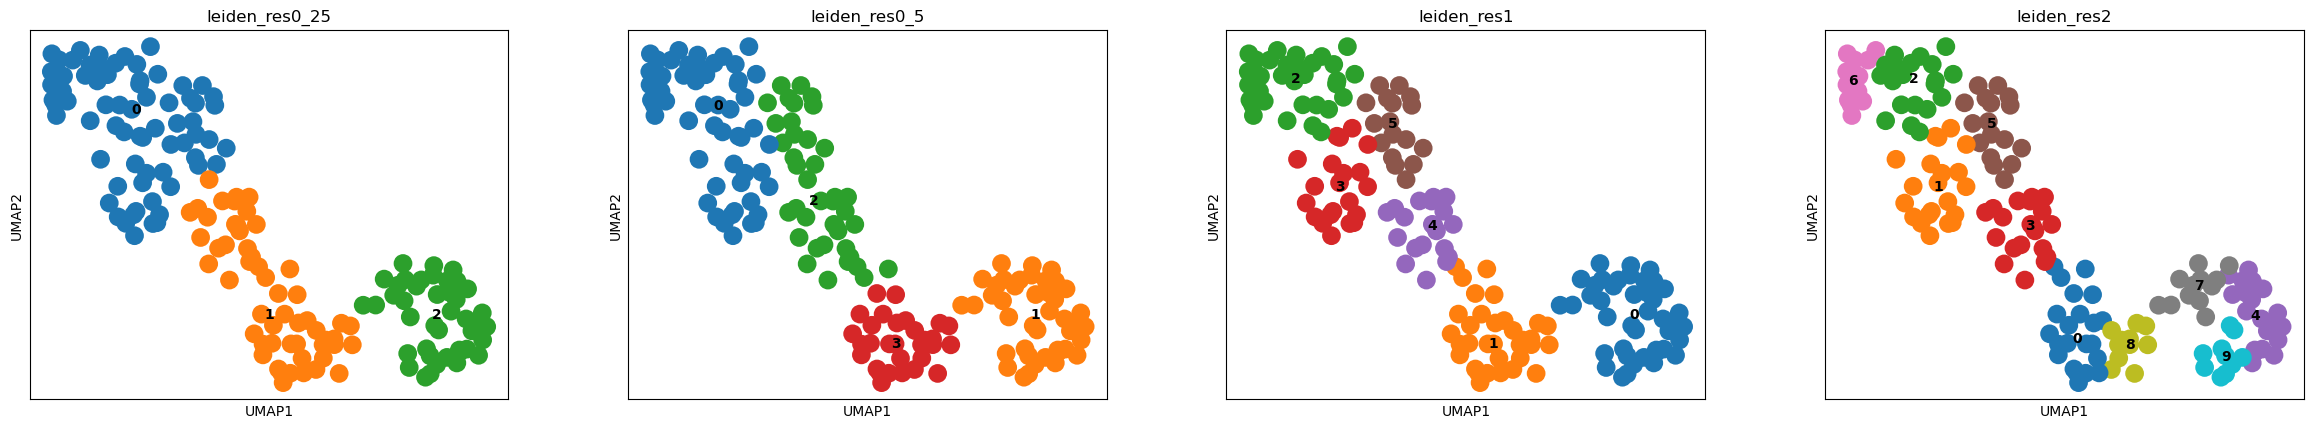

In [105]:
import scanpy as sc
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)

sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)
sc.tl.leiden(adata, key_added="leiden_res2", resolution=2.0)

sc.pl.umap(
    adata,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1", "leiden_res2"],
    legend_loc="on data",
)

# Annotation using celltypist
1. First we must transform the data so it is normalized to 10k counts per cell, then log1p-transformed.

In [106]:
# annotating cluster
adata.layers["counts"] = adata.X
adata_celltypist = adata.copy()
adata_celltypist.X = adata.layers["counts"]  # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

2. Import models from celltypist and predict cell types by comparing with these models. 

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 59
📂 Storing models in /Users/ashleyosuna/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl
🔬 Input data has 165 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 165 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with r

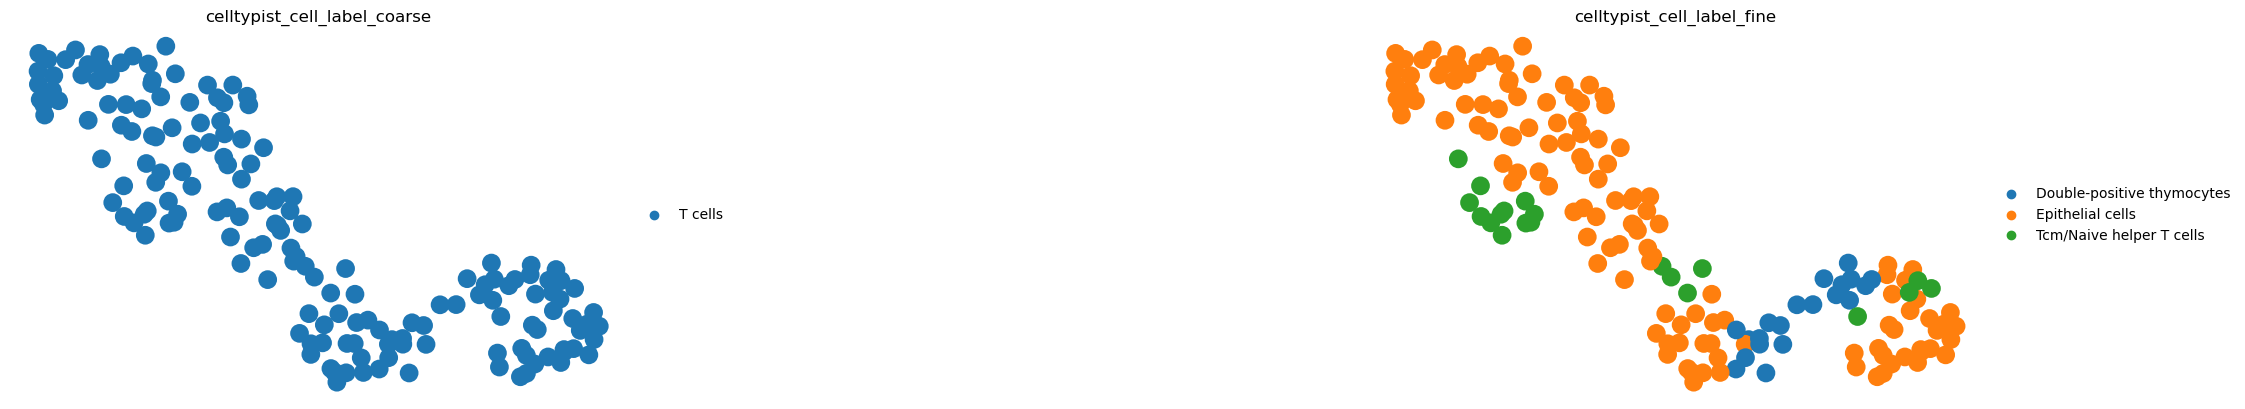

In [107]:
from celltypist import models
import celltypist

models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)

model_low = models.Model.load(model="Immune_All_Low.pkl")
model_high = models.Model.load(model="Immune_All_High.pkl")

predictions_high = celltypist.annotate(
    adata_celltypist, model=model_high, majority_voting=True
)

predictions_high_adata = predictions_high.to_adata()
adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]

predictions_low = celltypist.annotate(
    adata_celltypist, model=model_low, majority_voting=True
)
predictions_low_adata = predictions_low.to_adata()
adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "majority_voting"
]

sc.pl.umap(
    adata,
    color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine"],
    frameon=False,
    sort_order=False,
    wspace=1,
)